# Factorización de matrices SVD

En este cuadernillo se prueba el filtrado colaborativo basado en modelo, mediante factorización de matrices con SVD: cada usuario y cada película se representan con un vector de factores latentes, y el rating se predice como el producto de esos vectores (más, opcionalmente, un sesgo de usuario, de película y global). Se usa la librería surprise.

Documentación: https://surprise.readthedocs.io/en/stable/getting_started.html

In [1]:
import pandas as pd
from surprise import SVD, Dataset, Reader,accuracy
from scipy.sparse.linalg import svds
# from sklearn.metrics import mean_squared_error
from surprise.model_selection import GridSearchCV   #, KFold
import matplotlib.pyplot as plt

GridSearchCV de surprise necesita un objeto de split con el que particionar los datos en cada iteración. TrainValSplit se define para que, en vez de hacer varios folds de CV, entregue una única partición fija en la posición n_train: todo lo anterior es train y todo lo posterior es val.

In [2]:
class TrainValSplit:
    def __init__(self, n_train):
        self.n_train = n_train

    def split(self, data):
        raw = data.raw_ratings
        trainset = data.construct_trainset(raw[:self.n_train])
        valset = data.construct_testset(raw[self.n_train:])
        yield trainset, valset

    def get_n_folds(self):
        return 1

## Carga de datos
Se cargan los conjuntos de ratings ya particionados en train, val y test.

In [3]:
train = pd.read_parquet("../../data/03_model_ready/ratings_train.parquet")
test = pd.read_parquet("../../data/03_model_ready/ratings_test.parquet")
val =  pd.read_parquet("../../data/03_model_ready/ratings_val.parquet")

Se convierte test al formato que espera surprise: una lista de tuplas (userId, movieId, rating).

In [4]:
testset = list(test[['userId', 'movieId', 'rating']].itertuples(index=False, name=None))

Se instancia el split con n_train igual al tamaño de train, y se concatenan train y val en un único dataframe (full), respetando el orden. Al pasarlo por TrainValSplit, los primeros n_train registros se usan para entrenar y el resto (val) para validar en el grid search.

In [5]:
cv = TrainValSplit(n_train=len(train))
full = pd.concat([train[["userId", "movieId", "rating"]], val[["userId", "movieId", "rating"]]], ignore_index=True)
reader = Reader(rating_scale=(0.5, 5))
datos = Dataset.load_from_df(full, reader)

## SVD sin sesgos
Se define la rejilla de hiperparámetros para el grid search: número de factores latentes, número de épocas, learning rate y regularización. Con biased=False se usa la versión más simple de SVD, sin términos de sesgo de usuario, de película ni global.

In [ ]:
# Hiperparametros
param_grid = {
    'n_factors': [2,4,6,8,10,12,14],   # n factores latentes (n < f)
    'n_epochs':[70,80,90,100,110,120,130,140],     
    'lr_all':  [ 0.005,0.01,0.02],    # learning rate
    'reg_all':[ 0.01, 0.05, 0.1,0.2],    # regularización lambda
    'biased' : [False], #SVD sin sesgos
    'random_state': [73]
}

In [7]:
gsSVD = GridSearchCV(SVD,param_grid,measures=['rmse', 'mae'],cv=cv, n_jobs=-1)

In [8]:
gsSVD.fit(datos)

Mejor RMSE y MAE de validación encontrados, junto con la combinación de hiperparámetros correspondiente.

In [9]:
#MEJORES RESULTADOS entrenamiento
print(f"RMSE:  {gsSVD.best_score['rmse']:.3f}, {gsSVD.best_params['rmse']}")
print(f"MAE : {gsSVD.best_score['mae']:.3f}, {gsSVD.best_params['mae']}")

RMSE:  0.908, {'n_factors': 2, 'n_epochs': 140, 'lr_all': 0.01, 'reg_all': 0.1, 'biased': False, 'random_state': 73}
MAE : 0.695, {'n_factors': 2, 'n_epochs': 140, 'lr_all': 0.01, 'reg_all': 0.05, 'biased': False, 'random_state': 73}


Con la mejor configuración de hiperparámetros (según RMSE), se reentrena el modelo usando train+val al completo y se generan las predicciones sobre test.

In [41]:
#evaluacioN
# se reentrena con los mejores parametros y todos los datos train + val
trainset = datos.build_full_trainset() #objeto
modelo = SVD(**gsSVD.best_params['rmse'])
modelo.fit(trainset)
# Evaluar sobre test
predicciones = modelo.test(testset)

RMSE y MAE del modelo evaluado sobre los propios datos con los que se ha entrenado (train+val), para ver cómo de bien ajusta el modelo a los datos de entrenamiento.

In [ ]:
#ERROR RMSE SOBRE TRAIN+ VAL (ERROR SOBRE CONJUNTO ENTRENAMIENTO) SINSESGOS
p = modelo.test(trainset.build_testset())
rmse_train_val_sin = accuracy.rmse(p)
MAE_train_val_sin = accuracy.mae(p)

RMSE: 0.7836
MAE:  0.6055


RMSE y MAE finales sobre test.

In [ ]:
#TEST
rmse = accuracy.rmse(predicciones)
mae  = accuracy.mae(predicciones)

RMSE: 0.9194
MAE:  0.7082


## SVD con sesgos
Se repite el mismo proceso, pero con biased=True: el modelo añade un sesgo de usuario, un sesgo de película y un sesgo global a la predicción, además de los factores latentes. Como el modelo tiene más capacidad, se prueba con rejillas de n_factors y n_epochs distintas a las del caso sin sesgos.

In [ ]:
param_grid = {
    'n_factors': [10,15,20,25,30,35,40,45,50],   # n factores latentes (n < f)
    'n_epochs':[10,15,20,25,30,35,40,45],     # iteraciones
    'lr_all':  [0.01,0.02,0.03,0.05],    # learning rate alpha
    'reg_all':[0.01, 0.05, 0.1,0.2,0.3],    # regularización lambda
    'biased' : [True], #SVD com sesgos
    'random_state': [73]
}

In [13]:
gsSVDbiased = GridSearchCV(SVD,param_grid,measures=['rmse', 'mae'],cv=cv, n_jobs=-1) 

In [14]:
gsSVDbiased.fit(datos)

Mejor RMSE y MAE de validación encontrados con sesgos, junto con la combinación de hiperparámetros correspondiente.

In [15]:
#MEJORES RESULTADOS
print(f"RMSE:  {gsSVDbiased.best_score['rmse']:.3f}, {gsSVDbiased.best_params['rmse']}")
print(f"MAE : {gsSVDbiased.best_score['mae']:.3f}, {gsSVDbiased.best_params['mae']}")

RMSE:  0.863, {'n_factors': 40, 'n_epochs': 20, 'lr_all': 0.03, 'reg_all': 0.1, 'biased': True, 'random_state': 73}
MAE : 0.660, {'n_factors': 40, 'n_epochs': 15, 'lr_all': 0.05, 'reg_all': 0.1, 'biased': True, 'random_state': 73}


Con la mejor configuración, se reentrena el modelo con sesgos usando train+val al completo y se generan las predicciones sobre test.

In [46]:
#evaluacioN
trainset = datos.build_full_trainset() #objeto
modeloBiased = SVD(**gsSVDbiased.best_params['rmse'])
modeloBiased.fit(trainset)
# Evaluar sobre test
prediccionesBiased = modeloBiased.test(testset)

RMSE y MAE del modelo con sesgos evaluado sobre train+val, para ver cómo de bien ajusta a los datos de entrenamiento.

In [47]:
#ERROR RMSE SOBRE TRAIN+ VAL (ERROR SOBRE CONJUNTO ENTRENAMIENTO) SINSESGOS
p = modeloBiased.test(trainset.build_testset())
rmse_train_val_con = accuracy.rmse(p)
MAE_train_val_con = accuracy.mae(p)

RMSE: 0.6487
MAE:  0.5038


RMSE y MAE finales sobre test, con sesgos.

In [ ]:
# TEST CON SESGOS
rmseBiased = accuracy.rmse(prediccionesBiased)
maeBiased  = accuracy.mae(prediccionesBiased)

RMSE: 0.8608
MAE:  0.6627


Diferencia (en puntos de RMSE ×100) entre el RMSE de test sin sesgos y con sesgos: añadir los sesgos mejora el modelo en torno a 5,9 puntos.

In [23]:
(0.920-0.861)*100


5.900000000000006

## Análisis de hiperparámetros
Para cada valor de un hiperparámetro, se toma el mejor RMSE de validación entre todas las combinaciones del grid search que lo incluyen, y se representa frente a ese hiperparámetro. Así se ve el efecto de cada uno por separado, tanto para el modelo sin sesgos como para el modelo con sesgos.

RMSE frente al número de factores latentes, para el modelo sin sesgos.

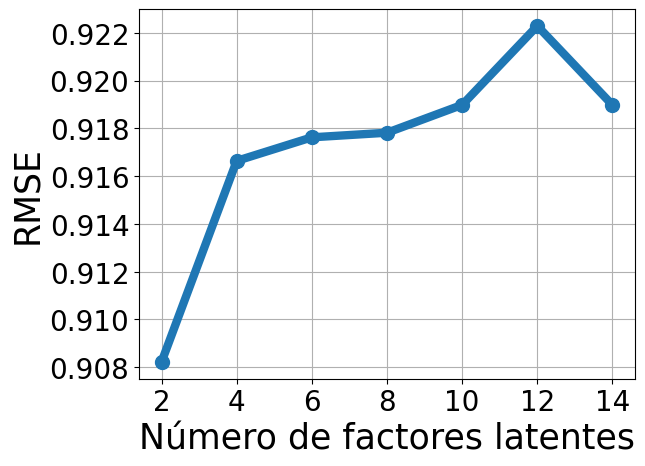

In [37]:
#RMSE vs n_factors (SIN biased) ENTRENAMIENTO
df_gs = pd.DataFrame(gsSVD.cv_results)
# para cada numero de factores se coge el menor RMSE de las combinaciones de parametros EN TEST pero de CV 
rmse_by_factors = df_gs.groupby('param_n_factors')['mean_test_rmse'].min()

plt.style.use('default')
plt.plot(rmse_by_factors.index, rmse_by_factors.values, marker='o', markersize=10, lw=6)
plt.xlabel('Número de factores latentes', fontsize=25)
# plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.3f}'))
plt.ylabel('RMSE', fontsize=25)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.grid()
plt.show()  

RMSE frente al número de épocas, para el modelo sin sesgos.

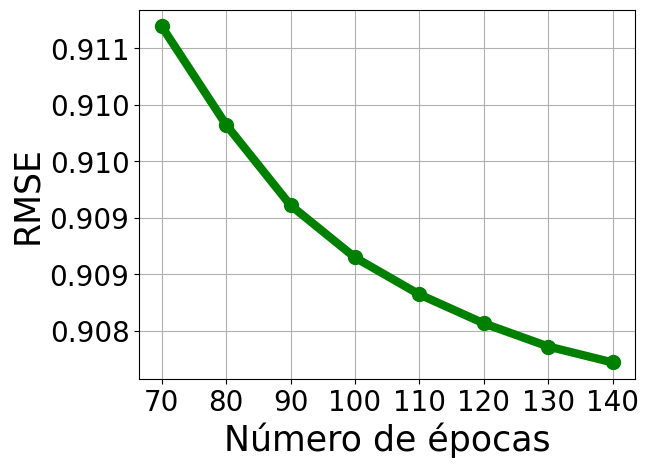

In [38]:
#RMSE vs n_epochs (biased=False)
df_gs2 = pd.DataFrame(gsSVD.cv_results)
rmse_by_epochs = df_gs2.groupby('param_n_epochs')['mean_test_rmse'].min()

plt.style.use('default')
plt.plot(rmse_by_epochs.index, rmse_by_epochs.values, marker='o', color='green', markersize=10, lw=6)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.3f}'))
plt.xlabel('Número de épocas', fontsize=25)
plt.ylabel('RMSE', fontsize=25)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.grid()
plt.show()

RMSE frente al número de factores latentes, para el modelo con sesgos.

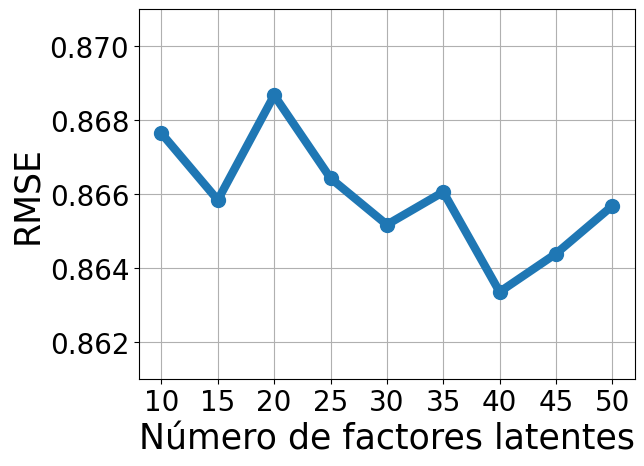

In [35]:
#RMSE vs n_factors (biased) ENTRENAMIENTO
df_gs = pd.DataFrame(gsSVDbiased.cv_results)
# para cada numero de factores se coge el menor RMSE de las combinaciones de parametros EN test pero de CV 
rmse_by_factors = df_gs.groupby('param_n_factors')['mean_test_rmse'].min()

plt.style.use('default')
plt.plot(rmse_by_factors.index, rmse_by_factors.values, marker='o', markersize=10, lw=6)
plt.xlabel('Número de factores latentes', fontsize=25)
plt.ylim(0.861,0.871)
plt.ylabel('RMSE', fontsize=25)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.grid()
plt.show()

RMSE frente al número de épocas, para el modelo con sesgos.

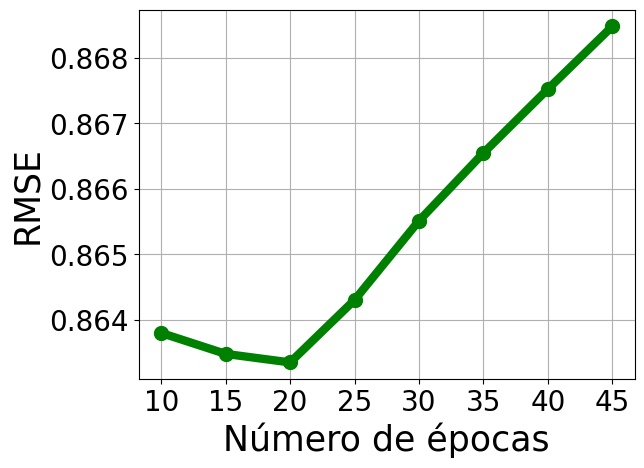

In [34]:
#RMSE vs n_epochs (biased=TRUE)
df_gs2 = pd.DataFrame(gsSVDbiased.cv_results)
rmse_by_epochs = df_gs2.groupby('param_n_epochs')['mean_test_rmse'].min()

plt.style.use('default')
plt.plot(rmse_by_epochs.index, rmse_by_epochs.values, marker='o', color='green', markersize=10, lw=6)
plt.xlabel('Número de épocas', fontsize=25)
plt.ylabel('RMSE', fontsize=25)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.grid()
plt.show()

## Modelo baseline de referencia
Como referencia, se prueba también BaselineOnly: un modelo mucho más simple que solo estima un sesgo por usuario y otro por película (sin factores latentes), calculados mediante ALS. Sirve para comprobar cuánto aportan realmente los factores latentes de SVD sobre un modelo tan simple.

In [50]:
# modelo baseline
from surprise import BaselineOnly

Rejilla de hiperparámetros para el grid search de BaselineOnly: número de épocas del método ALS, y la regularización de los sesgos de usuario (reg_u) y de película (reg_i).

In [ ]:
param_grid = {
    'bsl_options': {
        'method': ['als'],
        'n_epochs': [ 20, 30,40,50,60,70],
        'reg_u': [2,3,4,5,6,7,8,9,10],     # regularizacion de sesgos de usuario
        'reg_i': [1,2,3,4,5,6,7,8,9,10],     # regularizacion de sesgos de ítem
    },
    'verbose': [False], #mensajes de seguimiento
}

In [60]:
gsBase = GridSearchCV(BaselineOnly, param_grid, measures=['rmse', 'mae'], cv=cv, n_jobs=-1)
gsBase.fit(datos)
print(f"RMSE: {gsBase.best_score['rmse']:.3f}, {gsBase.best_params['rmse']}") #error en validacion

RMSE: 0.885, {'bsl_options': {'method': 'als', 'n_epochs': 70, 'reg_u': 5, 'reg_i': 3}, 'verbose': False}


Con la mejor configuración, se reentrena el modelo baseline con train+val al completo y se evalúa sobre test, así como sobre los propios datos de entrenamiento (train+val) como referencia de ajuste.

In [61]:
trainset = datos.build_full_trainset()
modeloBase = BaselineOnly(**gsBase.best_params['rmse'])
modeloBase.fit(trainset)

predsBase = modeloBase.test(testset)
print("test")
accuracy.rmse(predsBase)
accuracy.mae(predsBase)
print("entrenamiento: rms(val+train)")
accuracy.rmse(modeloBase.test(trainset.build_testset()))

test
RMSE: 0.8863
MAE:  0.6833
entrenamiento: rms(val+train)
RMSE: 0.8080


np.float64(0.8079630176852443)

## Resumen
Comparando el RMSE sobre test: SVD sin sesgos obtiene 0.9194, BaselineOnly 0.8863 y SVD con sesgos 0.8608. El modelo SVD con sesgos es el que mejor resultado consigue, mejorando incluso al baseline, lo que indica que los factores latentes sí aportan información útil una vez que el modelo ya tiene en cuenta los sesgos de usuario y de película.